# Reactivity Plots

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd().resolve()
while root != root.parent and not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from fusdb.relations.reactivities.nrl_reactivity_tables import (
    get_nrl_reactivity_table_path,
    load_nrl_reactivity_table,
)
from fusdb.relations.reactivities.reactivity_functions import (
    sigmav_DD_BoschHale,
    sigmav_DD_ENDFB_VIII0,
    sigmav_DD_total_NRL,
    sigmav_DHe3_BoschHale,
    sigmav_DHe3_ENDFB_VIII0,
    sigmav_DHe3_NRL,
    sigmav_DT_BoschHale,
    sigmav_DT_ENDFB_VIII0,
    sigmav_DT_NRL,
    sigmav_He3He3_CF88,
    sigmav_He3He3_ENDFB_VIII0,
    sigmav_THe3_CF88,
    sigmav_THe3_ENDFB_VIII0,
    sigmav_THe3_NRL,
    sigmav_TT_CF88,
    sigmav_TT_ENDFB_VIII0,
    sigmav_TT_NRL,
)

def sigmav_DD_total_BoschHale(temperature_keV):
    sigmav_total, _, _ = sigmav_DD_BoschHale(temperature_keV)
    return sigmav_total

def sigmav_DD_total_ENDFB_VIII0(temperature_keV):
    sigmav_total, _, _ = sigmav_DD_ENDFB_VIII0(temperature_keV)
    return sigmav_total

def sigmav_DDn_BoschHale(temperature_keV):
    _, sigmav_ddn, _ = sigmav_DD_BoschHale(temperature_keV)
    return sigmav_ddn

def sigmav_DDn_ENDFB_VIII0(temperature_keV):
    _, sigmav_ddn, _ = sigmav_DD_ENDFB_VIII0(temperature_keV)
    return sigmav_ddn

def sigmav_DDp_BoschHale(temperature_keV):
    _, _, sigmav_ddp = sigmav_DD_BoschHale(temperature_keV)
    return sigmav_ddp

def sigmav_DDp_ENDFB_VIII0(temperature_keV):
    _, _, sigmav_ddp = sigmav_DD_ENDFB_VIII0(temperature_keV)
    return sigmav_ddp

def sigmav_THe3_total_CF88(temperature_keV):
    sigmav_np, sigmav_d, sigmav_he5p = sigmav_THe3_CF88(temperature_keV)
    return sigmav_np + sigmav_d + sigmav_he5p

SERIES_SPECS = {
    "DT BoschHale": {
        "fn": sigmav_DT_BoschHale,
        "reaction": "DT",
        "method": "BoschHale",
        "label": "DT | BoschHale",
    },
    "DT ENDFB-VIII0": {
        "fn": sigmav_DT_ENDFB_VIII0,
        "reaction": "DT",
        "method": "ENDFB-VIII0",
        "label": "DT | ENDFB-VIII0",
    },
    "DT NRL": {
        "fn": sigmav_DT_NRL,
        "reaction": "DT",
        "method": "NRL",
        "label": "DT | NRL",
    },
    "DD total BoschHale": {
        "fn": sigmav_DD_total_BoschHale,
        "reaction": "DD total",
        "method": "BoschHale",
        "label": "DD total | BoschHale",
    },
    "DD total ENDFB-VIII0": {
        "fn": sigmav_DD_total_ENDFB_VIII0,
        "reaction": "DD total",
        "method": "ENDFB-VIII0",
        "label": "DD total | ENDFB-VIII0",
    },
    "DD total NRL": {
        "fn": sigmav_DD_total_NRL,
        "reaction": "DD total",
        "method": "NRL",
        "label": "DD total | NRL",
    },
    "DDn BoschHale": {
        "fn": sigmav_DDn_BoschHale,
        "reaction": "DDn",
        "method": "BoschHale",
        "label": "DDn | BoschHale",
    },
    "DDn ENDFB-VIII0": {
        "fn": sigmav_DDn_ENDFB_VIII0,
        "reaction": "DDn",
        "method": "ENDFB-VIII0",
        "label": "DDn | ENDFB-VIII0",
    },
    "DDp BoschHale": {
        "fn": sigmav_DDp_BoschHale,
        "reaction": "DDp",
        "method": "BoschHale",
        "label": "DDp | BoschHale",
    },
    "DDp ENDFB-VIII0": {
        "fn": sigmav_DDp_ENDFB_VIII0,
        "reaction": "DDp",
        "method": "ENDFB-VIII0",
        "label": "DDp | ENDFB-VIII0",
    },
    "DHe3 BoschHale": {
        "fn": sigmav_DHe3_BoschHale,
        "reaction": "DHe3",
        "method": "BoschHale",
        "label": "DHe3 | BoschHale",
    },
    "DHe3 ENDFB-VIII0": {
        "fn": sigmav_DHe3_ENDFB_VIII0,
        "reaction": "DHe3",
        "method": "ENDFB-VIII0",
        "label": "DHe3 | ENDFB-VIII0",
    },
    "DHe3 NRL": {
        "fn": sigmav_DHe3_NRL,
        "reaction": "DHe3",
        "method": "NRL",
        "label": "DHe3 | NRL",
    },
    "TT CF88": {
        "fn": sigmav_TT_CF88,
        "reaction": "TT",
        "method": "CF88",
        "label": "TT | CF88",
    },
    "TT ENDFB-VIII0": {
        "fn": sigmav_TT_ENDFB_VIII0,
        "reaction": "TT",
        "method": "ENDFB-VIII0",
        "label": "TT | ENDFB-VIII0",
    },
    "TT NRL": {
        "fn": sigmav_TT_NRL,
        "reaction": "TT",
        "method": "NRL",
        "label": "TT | NRL",
    },
    "He3He3 CF88": {
        "fn": sigmav_He3He3_CF88,
        "reaction": "He3He3",
        "method": "CF88",
        "label": "He3He3 | CF88",
    },
    "He3He3 ENDFB-VIII0": {
        "fn": sigmav_He3He3_ENDFB_VIII0,
        "reaction": "He3He3",
        "method": "ENDFB-VIII0",
        "label": "He3He3 | ENDFB-VIII0",
    },
    "THe3 CF88": {
        "fn": sigmav_THe3_total_CF88,
        "reaction": "THe3",
        "method": "CF88",
        "label": "THe3 | CF88",
    },
    "THe3 ENDFB-VIII0": {
        "fn": sigmav_THe3_ENDFB_VIII0,
        "reaction": "THe3",
        "method": "ENDFB-VIII0",
        "label": "THe3 | ENDFB-VIII0",
    },
    "THe3 NRL": {
        "fn": sigmav_THe3_NRL,
        "reaction": "THe3",
        "method": "NRL",
        "label": "THe3 | NRL",
    },
}

REACTIVITY_GROUPS = {
    "All": list(SERIES_SPECS),
    "DT": ["DT BoschHale", "DT ENDFB-VIII0", "DT NRL"],
    "DD": [
        "DD total BoschHale",
        "DD total ENDFB-VIII0",
        "DD total NRL",
        "DDn BoschHale",
        "DDn ENDFB-VIII0",
        "DDp BoschHale",
        "DDp ENDFB-VIII0",
    ],
    "DHe3": ["DHe3 BoschHale", "DHe3 ENDFB-VIII0", "DHe3 NRL"],
    "TT": ["TT CF88", "TT ENDFB-VIII0", "TT NRL"],
    "He3He3": ["He3He3 CF88", "He3He3 ENDFB-VIII0"],
    "THe3": ["THe3 CF88", "THe3 ENDFB-VIII0", "THe3 NRL"],
}

NRL_TOTAL_TABLES = {
    "DD total": "DD_total_NRL",
    "DT total": "DT_NRL",
    "DHe3": "DHe3_NRL",
    "TT": "TT_NRL",
    "THe3 total": "THe3_total_NRL",
}

REACTION_COLORS = {
    "DT": "tab:blue",
    "DD total": "tab:olive",
    "DDn": "tab:orange",
    "DDp": "goldenrod",
    "DHe3": "tab:green",
    "TT": "tab:red",
    "He3He3": "tab:purple",
    "THe3": "tab:brown",
}

METHOD_LINESTYLES = {
    "BoschHale": "-",
    "CF88": ":",
    "ENDFB-VIII0": "--",
    "NRL": "-.",
}

def plot_reactivity_group(group_name, *, x_limits=(1.0, 50.0), y_limits=(1e-26, 1e-21), num_points=1000):
    load_nrl_reactivity_table.cache_clear()
    series_names = REACTIVITY_GROUPS[group_name]
    temperature_keV = np.logspace(np.log10(x_limits[0]), np.log10(x_limits[1]), num_points)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(11, 7))

    for series_name in series_names:
        spec = SERIES_SPECS[series_name]
        values = np.asarray(spec["fn"](temperature_keV), dtype=float)
        values = np.clip(values, 1e-40, None)
        ax.plot(
            temperature_keV,
            values,
            label=spec["label"],
            color=REACTION_COLORS.get(spec["reaction"], "black"),
            linestyle=METHOD_LINESTYLES[spec["method"]],
            linewidth=2.2,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*x_limits)
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    ax.set_xlabel("Ion temperature [keV]")
    ax.set_ylabel(r"$\langle \sigma v \rangle$ [m$^3$/s]")
    ax.set_title(f"Fusion Reactivities: {group_name}")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.tight_layout()
    plt.show()

print("Available reaction groups:")
for group_name, series_names in REACTIVITY_GROUPS.items():
    print(f" - {group_name}: {series_names}")

print("\nNRL total-rate table files:")
for label, reaction_id in NRL_TOTAL_TABLES.items():
    path = get_nrl_reactivity_table_path(reaction_id)
    print(f" - {label}: {path.relative_to(root)}")


Available reaction groups:
 - All: ['DT BoschHale', 'DT ENDFB-VIII0', 'DT NRL', 'DD total BoschHale', 'DD total ENDFB-VIII0', 'DD total NRL', 'DDn BoschHale', 'DDn ENDFB-VIII0', 'DDp BoschHale', 'DDp ENDFB-VIII0', 'DHe3 BoschHale', 'DHe3 ENDFB-VIII0', 'DHe3 NRL', 'TT CF88', 'TT ENDFB-VIII0', 'TT NRL', 'He3He3 CF88', 'He3He3 ENDFB-VIII0', 'THe3 CF88', 'THe3 ENDFB-VIII0', 'THe3 NRL']
 - DT: ['DT BoschHale', 'DT ENDFB-VIII0', 'DT NRL']
 - DD: ['DD total BoschHale', 'DD total ENDFB-VIII0', 'DD total NRL', 'DDn BoschHale', 'DDn ENDFB-VIII0', 'DDp BoschHale', 'DDp ENDFB-VIII0']
 - DHe3: ['DHe3 BoschHale', 'DHe3 ENDFB-VIII0', 'DHe3 NRL']
 - TT: ['TT CF88', 'TT ENDFB-VIII0', 'TT NRL']
 - He3He3: ['He3He3 CF88', 'He3He3 ENDFB-VIII0']
 - THe3: ['THe3 CF88', 'THe3 ENDFB-VIII0', 'THe3 NRL']

NRL total-rate table files:
 - DD total: src/fusdb/relations/reactivities/tables/DD_total_reactivity_NRL.txt
 - DT total: src/fusdb/relations/reactivities/tables/DT_reactivity_NRL.txt
 - DHe3: src/fusdb/relati

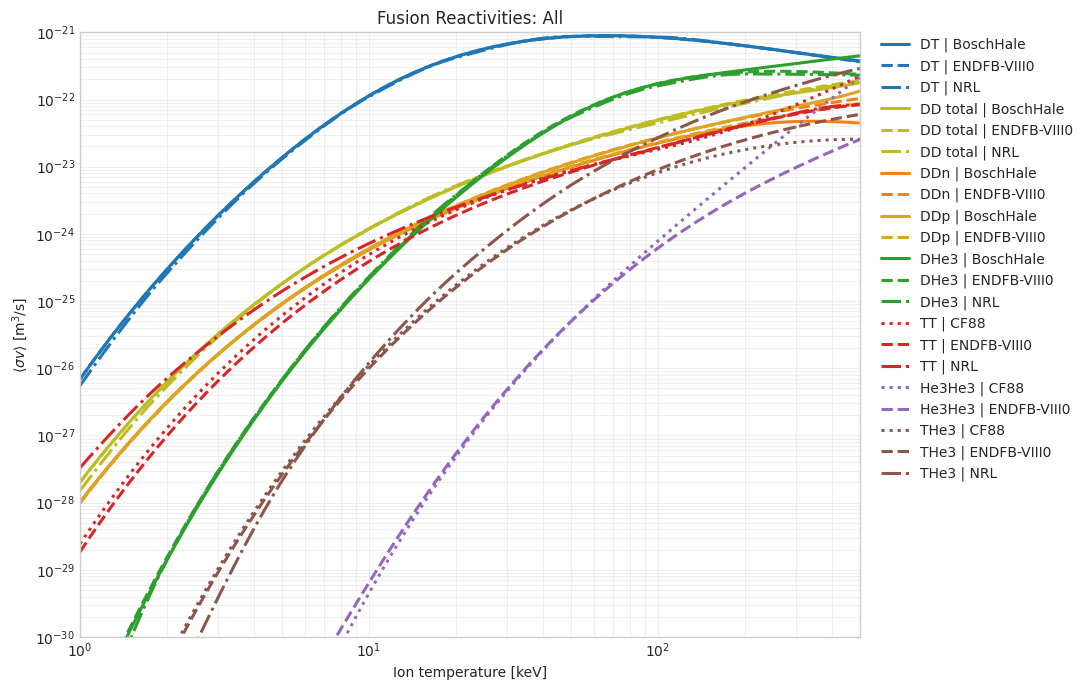

In [12]:
plot_reactivity_group("All", x_limits=(1,5e2), y_limits=(1e-30, 1e-21))


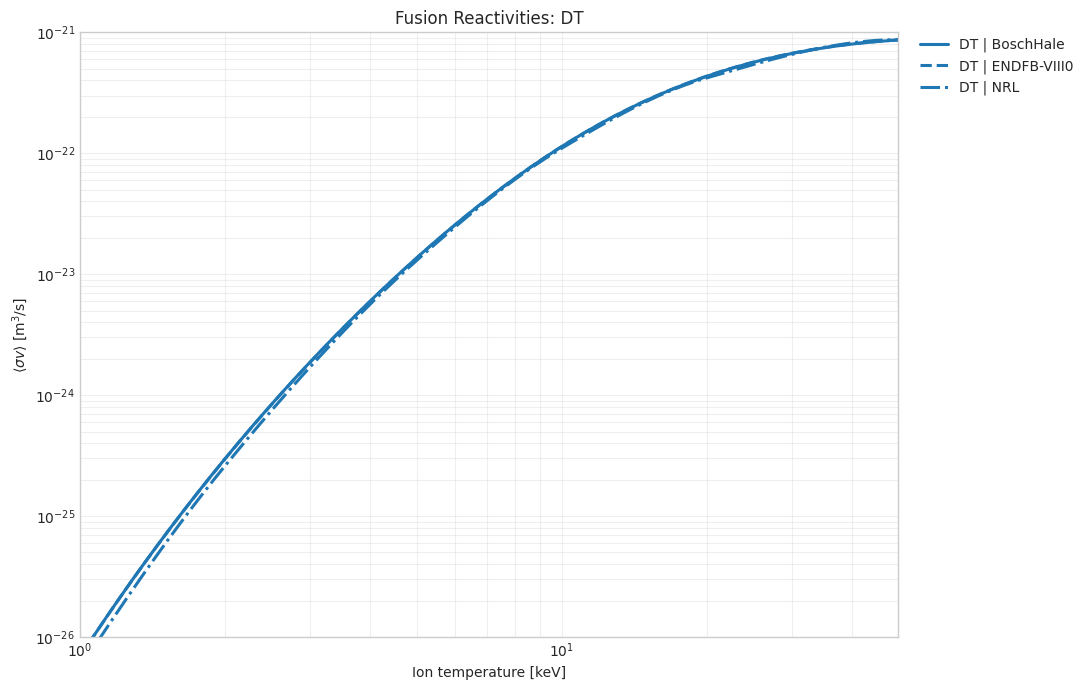

In [4]:
plot_reactivity_group("DT")


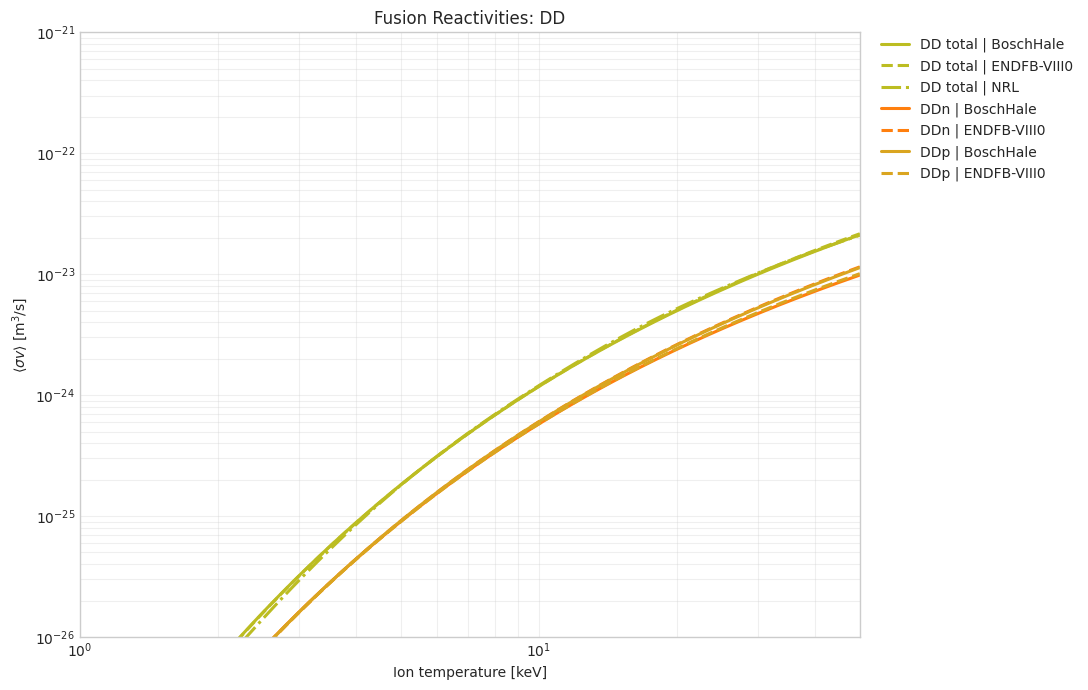

In [5]:
plot_reactivity_group("DD")


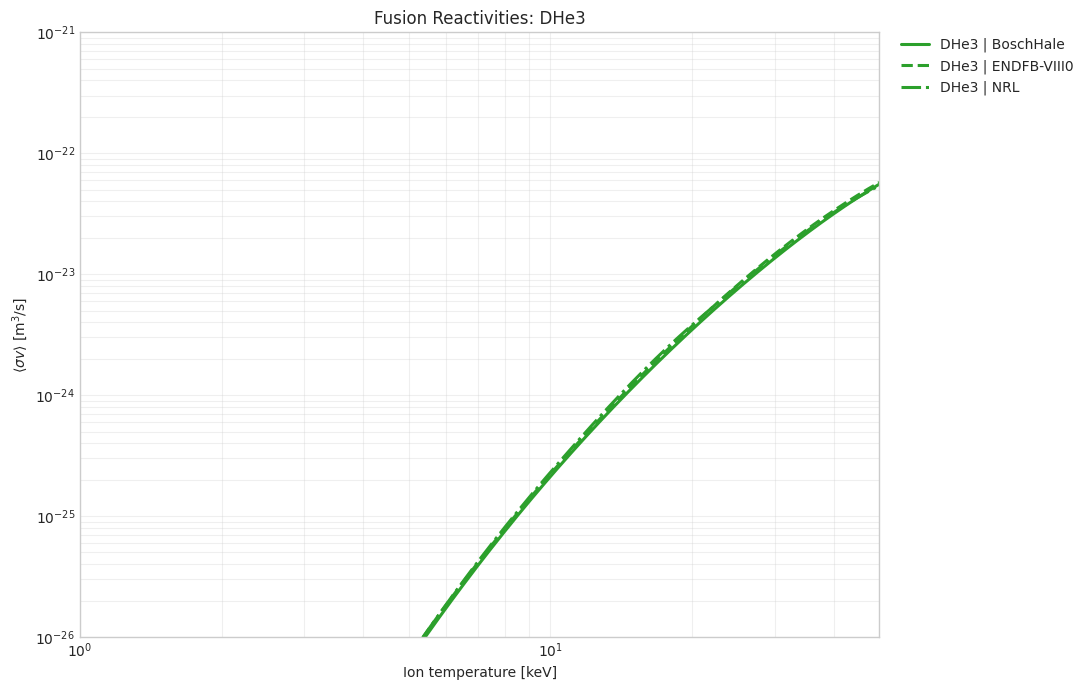

In [6]:
plot_reactivity_group("DHe3")


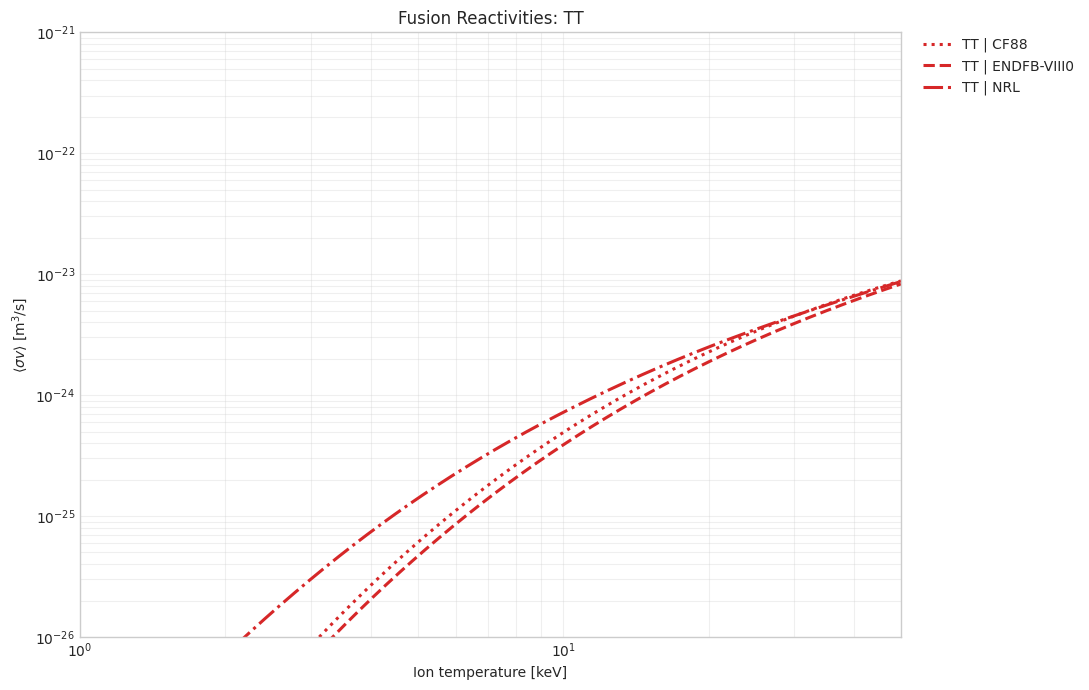

In [7]:
plot_reactivity_group("TT")


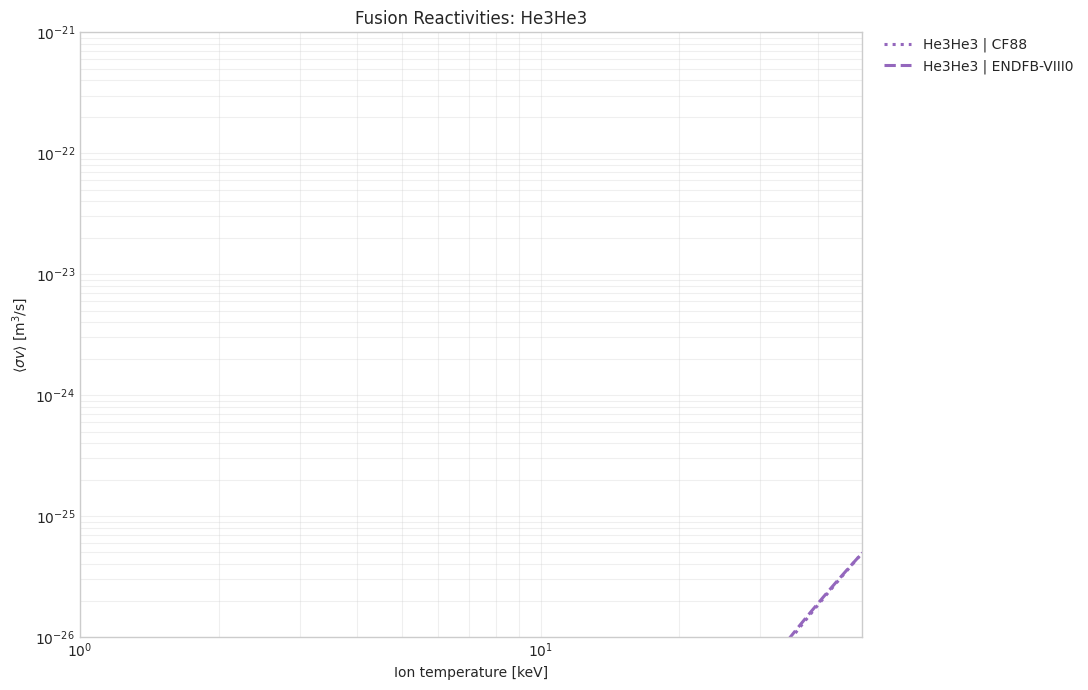

In [8]:
plot_reactivity_group("He3He3")


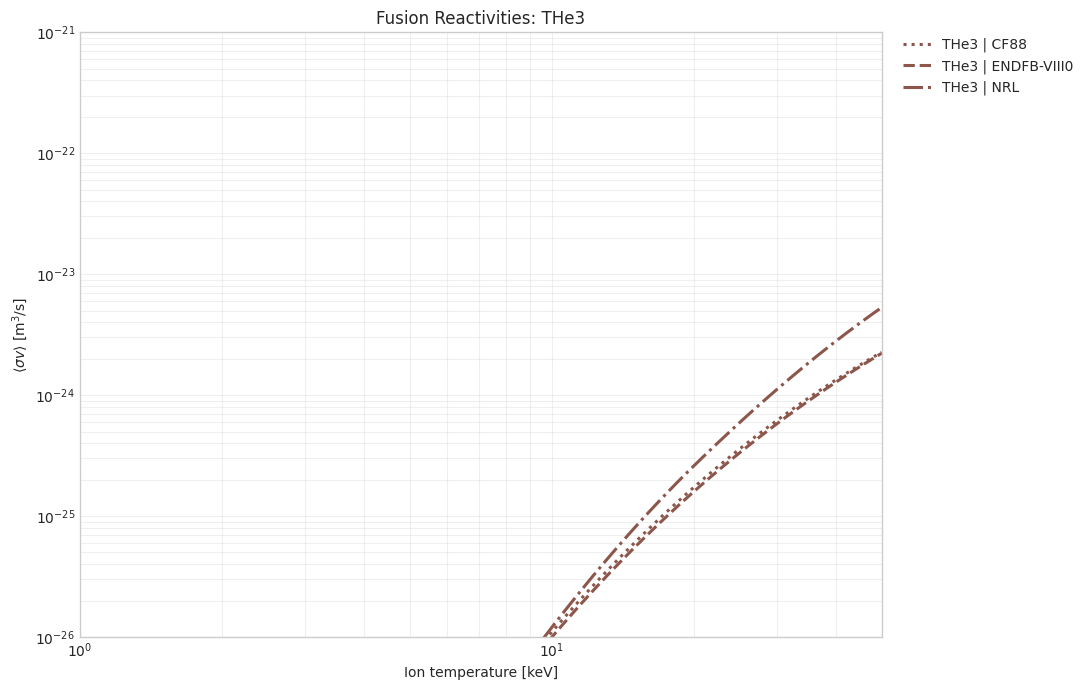

In [9]:
plot_reactivity_group("THe3")


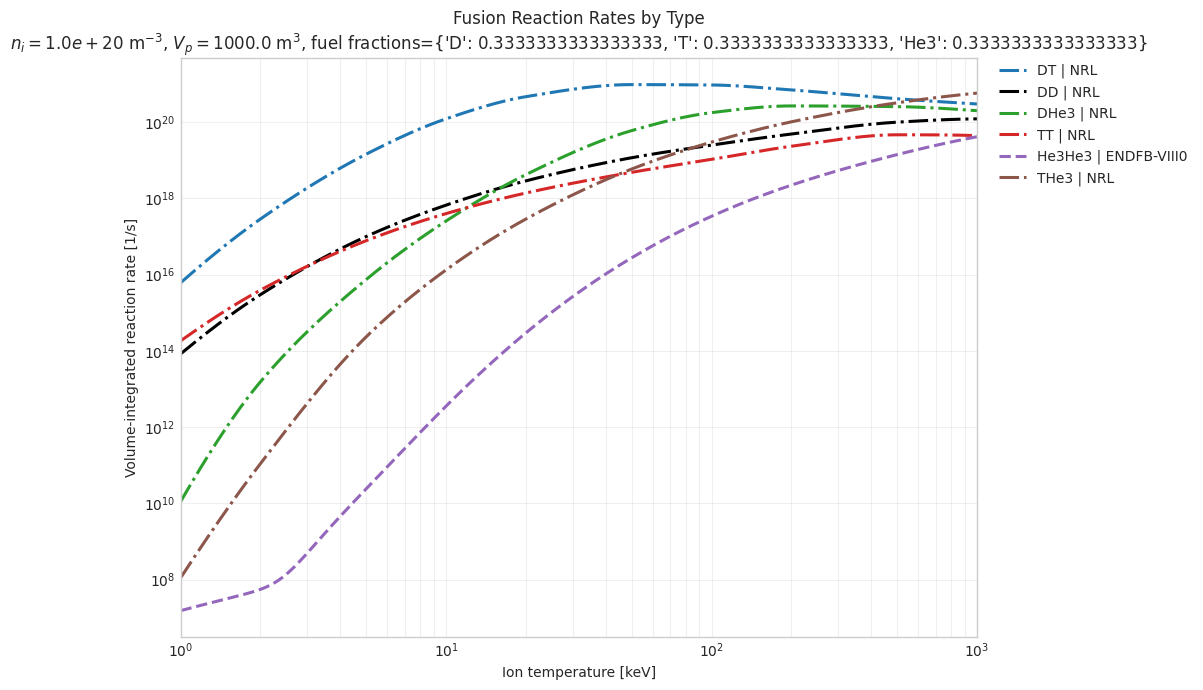

In [10]:
load_nrl_reactivity_table.cache_clear()

# User-editable assumptions for volume-integrated reaction rates.
reaction_rate_temperature_keV = np.logspace(0.0, 3.0, 400)
n_i = 1.0e20  # [m^-3]
V_p = 1000.0  # [m^3]
fuel_fractions = {
    "D": 1.0 / 3.0,
    "T": 1.0 / 3.0,
    "He3": 1.0 / 3.0,
}

# Choose one reactivity model per fusion type.
reaction_rate_reactivities = {
    "DT": ("NRL", sigmav_DT_NRL),
    "DD": ("NRL", sigmav_DD_total_NRL),
    "DHe3": ("NRL", sigmav_DHe3_NRL),
    "TT": ("NRL", sigmav_TT_NRL),
    "He3He3": ("ENDFB-VIII0", sigmav_He3He3_ENDFB_VIII0),
    "THe3": ("NRL", sigmav_THe3_NRL),
}

if any(value < 0.0 for value in fuel_fractions.values()):
    raise ValueError("Fuel fractions must be non-negative.")
if sum(fuel_fractions.values()) > 1.0 + 1.0e-12:
    raise ValueError("Fuel fractions should sum to at most 1.0.")

reaction_rate_prefactors = {
    "DT": fuel_fractions["D"] * fuel_fractions["T"],
    "DD": 0.5 * fuel_fractions["D"] ** 2,
    "DHe3": fuel_fractions["D"] * fuel_fractions["He3"],
    "TT": 0.5 * fuel_fractions["T"] ** 2,
    "He3He3": 0.5 * fuel_fractions["He3"] ** 2,
    "THe3": fuel_fractions["T"] * fuel_fractions["He3"],
}

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))

for reaction, (method, reactivity_fn) in reaction_rate_reactivities.items():
    sigmav = np.asarray(reactivity_fn(reaction_rate_temperature_keV), dtype=float)
    rates = reaction_rate_prefactors[reaction] * (n_i ** 2) * sigmav * V_p
    rates = np.clip(rates, 1e-40, None)
    ax.plot(
        reaction_rate_temperature_keV,
        rates,
        label=f"{reaction} | {method}",
        color=REACTION_COLORS.get(reaction, "black"),
        linestyle=METHOD_LINESTYLES.get(method, "-"),
        linewidth=2.2,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.0, 1000.0)
ax.set_xlabel("Ion temperature [keV]")
ax.set_ylabel("Volume-integrated reaction rate [1/s]")
ax.set_title(
    "Fusion Reaction Rates by Type\n"
    f"$n_i={n_i:.1e}$ m$^{{-3}}$, $V_p={V_p:.1f}$ m$^3$, fuel fractions={fuel_fractions}"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.tight_layout()
plt.show()


In [11]:
load_nrl_reactivity_table.cache_clear()

for label, reaction_id in NRL_TOTAL_TABLES.items():
    path = get_nrl_reactivity_table_path(reaction_id)
    print(f"\n{label} ({path.relative_to(root)})")
    table = load_nrl_reactivity_table(reaction_id)
    print(f"{'T_i [keV]':>12} {'<sigma v> [cm^3/s]':>22} {'<sigma v> [m^3/s]':>22}")
    for temperature_keV, sigmav_m3_per_s in zip(
        table.temperature_grid_keV,
        table.reactivity_grid_m3_per_s,
        strict=True,
    ):
        print(f"{temperature_keV:12.3f} {sigmav_m3_per_s * 1.0e6:22.6e} {sigmav_m3_per_s:22.6e}")



DD total (src/fusdb/relations/reactivities/tables/DD_total_reactivity_NRL.txt)
   T_i [keV]     <sigma v> [cm^3/s]      <sigma v> [m^3/s]
       1.000           1.500000e-22           1.500000e-28
       2.000           5.400000e-21           5.400000e-27
       5.000           1.800000e-19           1.800000e-25
      10.000           1.200000e-18           1.200000e-24
      20.000           5.200000e-18           5.200000e-24
      50.000           2.100000e-17           2.100000e-23
     100.000           4.500000e-17           4.500000e-23
     200.000           8.800000e-17           8.800000e-23
     500.000           1.800000e-16           1.800000e-22
    1000.000           2.200000e-16           2.200000e-22

DT total (src/fusdb/relations/reactivities/tables/DT_reactivity_NRL.txt)
   T_i [keV]     <sigma v> [cm^3/s]      <sigma v> [m^3/s]
       1.000           5.500000e-21           5.500000e-27
       2.000           2.600000e-19           2.600000e-25
       5.000        